# # Notebook 03 — ResNet-18 + Physics-Motivated Augmentation
# **DeepLense GSoC 2026 Evaluation**
# Same architecture as NB02 with augment=True. Controlled experiment —
# only one variable changes. Proves orientation bias via accuracy drop.

In [1]:
# %% [Cell 1: Mount Google Drive & Set Workspace]
import os, sys
 
from google.colab import drive
drive.mount('/content/drive')
 
BASE_DIR = "/content/drive/My Drive/DeepLense_GSoC_Data"
SRC_DIR  = os.path.join(BASE_DIR, "src")
 
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)
 
print(f"✅ Workspace : {BASE_DIR}")
print(f"✅ src/ path : {SRC_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Workspace : /content/drive/My Drive/DeepLense_GSoC_Data
✅ src/ path : /content/drive/My Drive/DeepLense_GSoC_Data/src


In [2]:
# %% [Cell 2: WandB Authentication — Key loaded from .env file]
import os
import wandb
from dotenv import load_dotenv

load_dotenv(os.path.join(BASE_DIR, ".env"))
wandb.login(key=os.getenv("WANDB_API_KEY"))
print("✅ WandB authenticated successfully")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: diminiax (diminiax-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ WandB authenticated successfully


In [3]:
# %% [Cell 3: Install Dependencies & Verify GPU]
# ── Install from pinned requirements — fixes numpy binary incompatibility ─
!pip install -q -r "/content/drive/My Drive/DeepLense_GSoC_Data/requirements.txt"

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🖥️  Device : {device}")
if device.type == 'cuda':
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")


🖥️  Device : cuda
   GPU    : Tesla T4


In [4]:
# %% [Cell 3: Imports & Reproducibility Seed]
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm
 
from dataset import get_dataloaders, stage_data_locally
from models  import ResNetTransfer
from metrics import (
    save_confusion_matrix,
    generate_classification_report,
    plot_multiclass_roc_auc,
    plot_learning_curves,
)
 
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False
 
set_seed(42)
print("✅ Seed set to 42 — deterministic training enabled")

✅ Seed set to 42 — deterministic training enabled


In [ ]:
# %% [Cell 4: Stage Data & Build DataLoaders WITH Augmentation]
ZIP_PATH = os.path.join(BASE_DIR, "dataset.zip")
CSV_NAME = "metadata.csv"
 
staged_dir = stage_data_locally(ZIP_PATH)
data_dir   = staged_dir if staged_dir else BASE_DIR
csv_path   = os.path.join(data_dir, CSV_NAME)
 
print(f"📂 Data directory : {data_dir}")
print(f"📄 CSV path       : {csv_path}")
 
# ── Build DataLoaders WITH augmentation ───────────────────────────────────
# This is the key difference from Notebook 02 — augment=True
#
# Physics-motivated augmentation choices (defined in dataset.py):
#   RandomHorizontalFlip(0.5)  — no preferred axis in lensing geometry
#   RandomVerticalFlip(0.5)    — no preferred axis in lensing geometry
#   RandomRotation(360)        — full rotational symmetry (upgraded from 30° in v1)
#   GaussianBlur               — simulates telescope PSF smearing
#
# FIX v1: Image size upgraded 64×64 → 224×224 (matches ImageNet weights)
# FIX v1: RandomRotation upgraded 30° → 360° (physically correct — full symmetry)
# FIX v1: val_transform is CLEAN (no augmentation) — leakage fixed via dataset.py
# FIX v2: get_dataloaders now returns a 6-tuple (adds test_loader + test_df)
train_loader, val_loader, _, train_df, val_df, _ = get_dataloaders(
    csv_path   = csv_path,
    base_dir   = data_dir,
    mode       = 'RGB',
    image_size = 224,       # FIX: was 64 in v1
    batch_size = 32,
    augment    = True,      # KEY DIFFERENCE from Notebook 02
)
 
print(f"\n✅ Train batches : {len(train_loader)} ({len(train_df)} images)")
print(f"✅ Val batches   : {len(val_loader)}   ({len(val_df)} images)")
print(f"\n🔬 Augmentation pipeline active on training set:")
print(f"   • RandomHorizontalFlip(p=0.5)  — no preferred axis in lensing")
print(f"   • RandomVerticalFlip(p=0.5)    — no preferred axis in lensing")
print(f"   • RandomRotation(360°)         — full rotational symmetry (FIX: was 30° in v1)")
print(f"   • GaussianBlur(σ=0.1–1.0)     — simulates telescope PSF smearing")
print(f"   Val set uses CLEAN transform   — zero augmentation, deterministic")

✅ Local staging already complete at: /content/local_dataset
📂 Data directory : /content/local_dataset
📄 CSV path       : /content/local_dataset/metadata.csv

📊 Dataset Class Distribution:
   cdm        :   500 samples  (33.3%)
   no_sub     :   500 samples  (33.3%)
   vortex     :   500 samples  (33.3%)
   TOTAL      :  1500 samples

✅ Split — Train: 1050 | Val: 225 | Test: 225

✅ Train batches : 32 (1050 images)
✅ Val batches   : 8   (225 images)

🔬 Augmentation pipeline active on training set:
   • RandomHorizontalFlip(p=0.5)  — no preferred axis in lensing
   • RandomVerticalFlip(p=0.5)    — no preferred axis in lensing
   • RandomRotation(360°)         — full rotational symmetry (FIX: was 30° in v1)
   • GaussianBlur(σ=0.1–1.0)     — simulates telescope PSF smearing
   Val set uses CLEAN transform   — zero augmentation, deterministic


In [6]:
# %% [Cell 5: Model, Loss, Optimizer, Scheduler]
# ── Model ─────────────────────────────────────────────────────────────────
# Same architecture as Notebook 02 — ResNetTransfer with ImageNet weights.
# The ONLY variable changing between NB02 and NB03 is augmentation.
# This is a controlled scientific experiment — one variable at a time.
model = ResNetTransfer(num_classes=3, freeze_backbone=False).to(device)
print(f"🧠 Model      : ResNetTransfer (ImageNet weights)")
print(f"   Input      : (B, 3, 224, 224) — RGB, ImageNet-normalised")
print(f"   Strategy   : Full fine-tuning — identical to Notebook 02")
print(f"   Variable   : augment=True  ← only change from NB02")
 
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Trainable params: {trainable_params:,}")
 
criterion = nn.CrossEntropyLoss()
 
# ── Optimizer ─────────────────────────────────────────────────────────────
# Same LR as NB02 for fair comparison
LEARNING_RATE = 1e-4
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
 
# ── LR Scheduler ─────────────────────────────────────────────────────────
# More epochs than NB02 (15 vs 10) — augmentation slows convergence
# because every sample looks different each epoch. The model needs more
# passes to extract stable feature representations from the augmented data.
EPOCHS    = 15
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-7)
 
print(f"\n⚙️  Optimizer  : Adam (lr={LEARNING_RATE})")
print(f"⚙️  Scheduler  : CosineAnnealingLR (T_max={EPOCHS})")
print(f"⚙️  Epochs     : {EPOCHS}  (more than NB02 — augmentation slows convergence)")
 
ASSETS_DIR  = os.path.join(BASE_DIR, "assets")
WEIGHTS_DIR = os.path.join(BASE_DIR, "weights")
os.makedirs(ASSETS_DIR,  exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)

🧠 Model      : ResNetTransfer (ImageNet weights)
   Input      : (B, 3, 224, 224) — RGB, ImageNet-normalised
   Strategy   : Full fine-tuning — identical to Notebook 02
   Variable   : augment=True  ← only change from NB02
   Trainable params: 11,178,051

⚙️  Optimizer  : Adam (lr=0.0001)
⚙️  Scheduler  : CosineAnnealingLR (T_max=15)
⚙️  Epochs     : 15  (more than NB02 — augmentation slows convergence)


In [7]:
# %% [Cell 6: Training Loop]
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
 
best_val_acc = 0.0
best_epoch   = 0
best_weights = None
 
print(f"🚀 Starting Augmented Training — {EPOCHS} epochs\n")
 
for epoch in range(EPOCHS):
 
    # ── TRAIN ─────────────────────────────────────────────────────────────
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
 
    pbar = tqdm(train_loader, desc=f"  Epoch {epoch+1}/{EPOCHS} [Train]", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
 
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
 
        t_loss    += loss.item()
        _, preds   = torch.max(logits, 1)
        t_total   += labels.size(0)
        t_correct += (preds == labels).sum().item()
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{100*t_correct/t_total:.1f}%")
 
    train_loss = t_loss / len(train_loader)
    train_acc  = 100.0 * t_correct / t_total
 
    # ── VALIDATE ──────────────────────────────────────────────────────────
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
 
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            logits  = model(images)
            v_loss    += criterion(logits, labels).item()
            _, preds   = torch.max(logits, 1)
            v_total   += labels.size(0)
            v_correct += (preds == labels).sum().item()
 
    val_loss = v_loss / len(val_loader)
    val_acc  = 100.0 * v_correct / v_total
 
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
 
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
 
    is_best = val_acc > best_val_acc
    if is_best:
        best_val_acc = val_acc
        best_epoch   = epoch + 1
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        torch.save(best_weights, os.path.join(WEIGHTS_DIR, "augmented_best.pth"))
 
    print(
        f"  Epoch {epoch+1:>2}/{EPOCHS} │ "
        f"Train  loss={train_loss:.4f}  acc={train_acc:.1f}% │ "
        f"Val  loss={val_loss:.4f}  acc={val_acc:.1f}% │ "
        f"LR={current_lr:.2e}"
        + (" ✅ best" if is_best else "")
    )
 
torch.save(model.state_dict(), os.path.join(WEIGHTS_DIR, "augmented_final.pth"))
print(f"\n💾 Final weights → weights/augmented_final.pth")
print(f"💾 Best weights  → weights/augmented_best.pth  (epoch {best_epoch}, val_acc={best_val_acc:.1f}%)")

🚀 Starting Augmented Training — 15 epochs



  Epoch  1/15 │ Train  loss=1.0422  acc=47.3% │ Val  loss=1.1280  acc=52.4% │ LR=9.89e-05 ✅ best


  Epoch  2/15 │ Train  loss=0.9341  acc=54.1% │ Val  loss=0.9478  acc=57.8% │ LR=9.57e-05 ✅ best


  Epoch  3/15 │ Train  loss=0.8583  acc=59.0% │ Val  loss=0.7255  acc=58.7% │ LR=9.05e-05 ✅ best


  Epoch  4/15 │ Train  loss=0.8051  acc=62.8% │ Val  loss=0.9811  acc=61.3% │ LR=8.35e-05 ✅ best


...

  Epoch 11/15 │ Train  loss=0.5956  acc=74.4% │ Val  loss=0.6393  acc=72.4% │ LR=1.66e-05


  Epoch 12/15 │ Train  loss=0.5782  acc=75.3% │ Val  loss=0.6892  acc=72.0% │ LR=9.64e-06


  Epoch 13/15 │ Train  loss=0.5617  acc=76.3% │ Val  loss=0.6850  acc=70.7% │ LR=4.42e-06


  Epoch 14/15 │ Train  loss=0.5476  acc=76.8% │ Val  loss=0.6806  acc=71.6% │ LR=1.19e-06


  Epoch 15/15 │ Train  loss=0.5456  acc=76.2% │ Val  loss=0.6800  acc=71.1% │ LR=1.00e-07

💾 Final weights → weights/augmented_final.pth
💾 Best weights  → weights/augmented_best.pth  (epoch 5, val_acc=72.4%)


📊 Learning curves saved → /content/drive/My Drive/DeepLense_GSoC_Data/assets/augmented_learning_curves.png


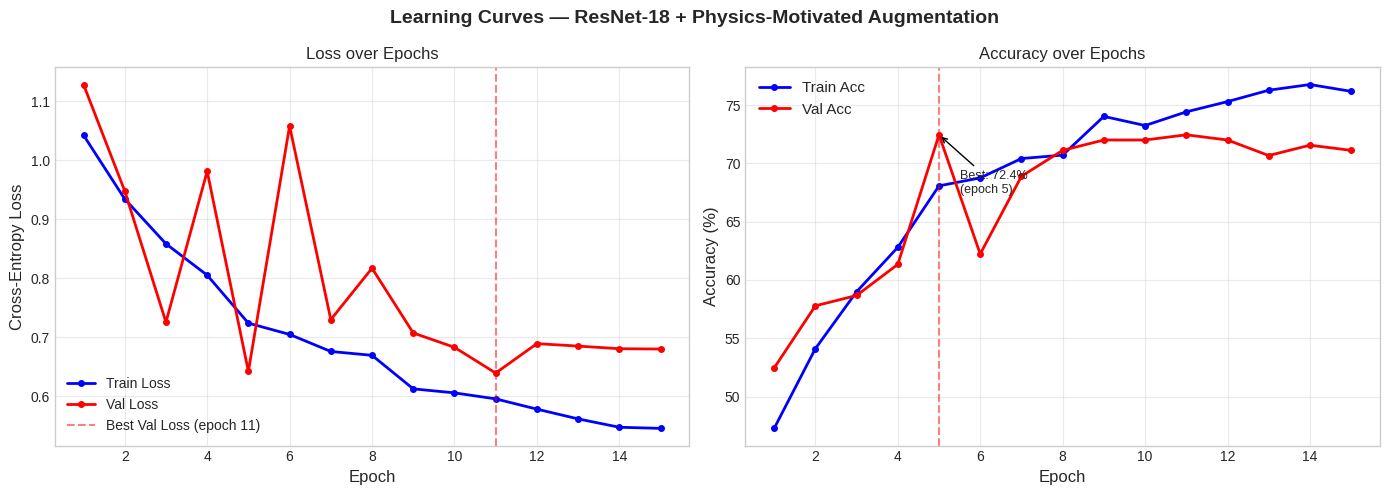

In [8]:
# %% [Cell 7: Learning Curves Plot]
# With augmentation, expect train_acc to be LOWER than NB02 train_acc.
# This is normal — augmentation makes every batch harder, so training accuracy
# is a noisier signal. The important number is val_acc, which should be
# more stable and generalise better to unseen data.
plot_learning_curves(
    train_losses = train_losses,
    val_losses   = val_losses,
    train_accs   = train_accs,
    val_accs     = val_accs,
    save_path    = os.path.join(ASSETS_DIR, "augmented_learning_curves.png"),
    model_name   = "ResNet-18 + Physics-Motivated Augmentation",
)

In [9]:
# %% [Cell 8: Evaluation — Restore Weights & Run Inference]
# Load best weights directly from Drive — skip retraining
model.load_state_dict(
    torch.load(os.path.join(WEIGHTS_DIR, "augmented_best.pth"), map_location=device)
)
model.eval()
 
all_preds  = []
all_labels = []
all_probs  = []
 
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        probs  = F.softmax(logits, dim=1)
 
        _, preds = torch.max(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
 
all_probs = np.array(all_probs)
CLASSES   = ['No Sub', 'CDM', 'Vortex']
 
# FIX v2: Capture return dict so f1_macro flows into AUGMENTED_RESULTS
report = generate_classification_report(
    all_labels, all_preds,
    classes    = CLASSES,
    model_name = "ResNet-18 + Augmentation",
)


  CLASSIFICATION REPORT  —  ResNet-18 + Augmentation
              precision    recall  f1-score   support

      No Sub     0.7576    1.0000    0.8621        75
         CDM     0.6721    0.5467    0.6029        75
      Vortex     0.7231    0.6267    0.6714        75

    accuracy                         0.7244       225
   macro avg     0.7176    0.7244    0.7121       225
weighted avg     0.7176    0.7244    0.7121       225

  Macro F1        : 0.7121  ← use in result dicts
  Weighted F1     : 0.7121
  Macro Precision : 0.7176
  Macro Recall    : 0.7244



📊 Confusion matrix saved → /content/drive/My Drive/DeepLense_GSoC_Data/assets/augmented_confusion_matrix.png


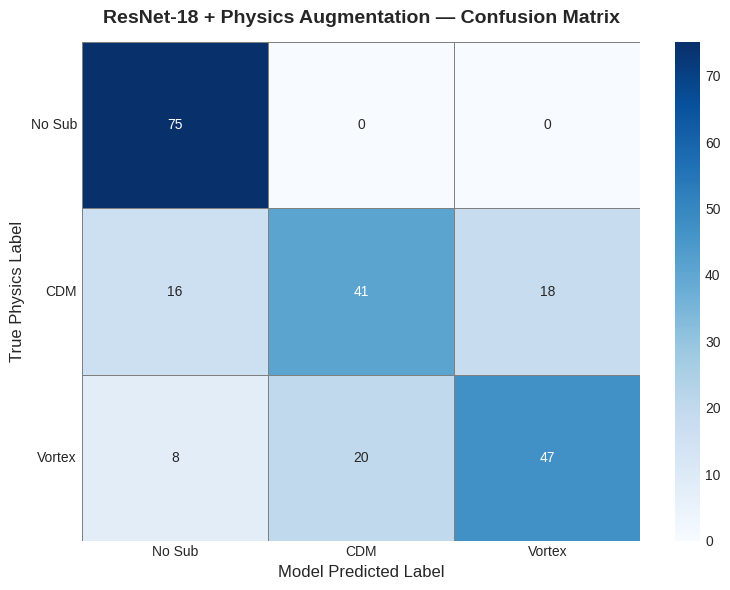


  ROC-AUC & PHYSICS REPORT  —  ResNet-18 + Physics-Motivated Augmentation
  No Sub      : AUC = 0.9547  |  FPR @ 90% TPR = 0.1133
  CDM         : AUC = 0.7914  |  FPR @ 90% TPR = 0.5000
  Vortex      : AUC = 0.8428  |  FPR @ 90% TPR = 0.4267
  -------------------------------------------------------------
  Micro-Avg   : AUC = 0.8747  |  FPR @ 90% TPR = 0.3711
  Macro-Avg   : AUC = 0.8629  |  FPR @ 90% TPR = 0.3467

📊 ROC curve saved → /content/drive/My Drive/DeepLense_GSoC_Data/assets/augmented_roc_auc.png


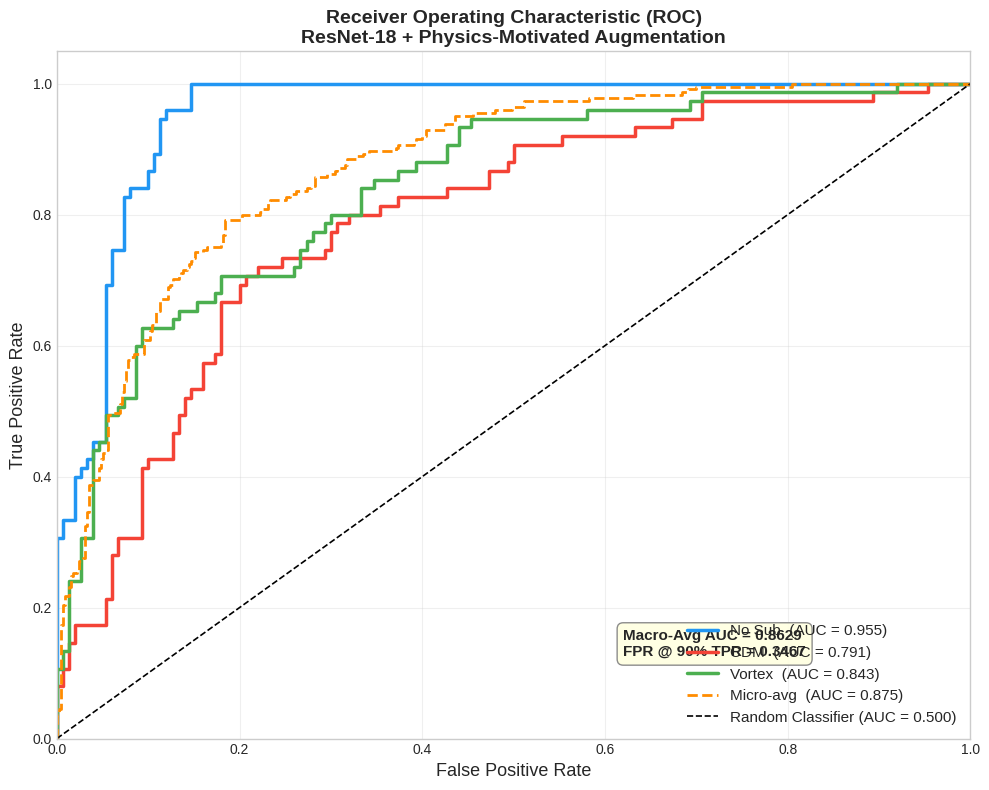

In [10]:
# %% [Cell 9: Confusion Matrix & ROC-AUC Plots]
save_confusion_matrix(
    all_labels, all_preds,
    classes   = CLASSES,
    save_path = os.path.join(ASSETS_DIR, "augmented_confusion_matrix.png"),
    title     = "ResNet-18 + Physics Augmentation — Confusion Matrix",
    cmap      = "Blues",
)
 
auc_scores = plot_multiclass_roc_auc(
    all_labels, all_probs,
    classes    = CLASSES,
    save_path  = os.path.join(ASSETS_DIR, "augmented_roc_auc.png"),
    model_name = "ResNet-18 + Physics-Motivated Augmentation",
)

In [ ]:
# %% [Cell 10: Results Dict & Augmentation Impact Analysis]
AUGMENTED_RESULTS = {
    'model':        'ResNet-18 + Augmentation',
    'val_acc':      best_val_acc,
    'macro_auc':    auc_scores['macro'],
    'cdm_auc':      auc_scores['per_class'][1],
    'fpr_90_macro': auc_scores['fpr_90_macro'],
    'f1_macro':     report['f1_macro'],   # FIX v2: was hardcoded 0.0
}
 
print("\n📌 AUGMENTED_RESULTS (paste into Notebook 06):")
print(AUGMENTED_RESULTS)
 
# ── Direct comparison: NB02 vs NB03 ──────────────────────────────────────
# Paste your NB02 best_val_acc here for the comparison
NB02_VAL_ACC = 92.33   # <── from your Notebook 02 output
 
print("=" * 55)
print("  AUGMENTATION IMPACT ANALYSIS")
print("=" * 55)
print(f"  NB02 — Transfer (no aug)  : val_acc = {NB02_VAL_ACC:.2f}%")
print(f"  NB03 — Transfer + aug     : val_acc = {best_val_acc:.2f}%")
delta = best_val_acc - NB02_VAL_ACC
direction = "📈 improvement" if delta > 0 else "📉 trade-off"
print(f"  Delta                     : {delta:+.2f}%  {direction}")
print("=" * 55)
print()
print("  Scientific interpretation:")
print("  Augmentation regularises the model — the train/val gap")
print("  in the learning curves should be smaller than NB02.")
print("  If val_acc is slightly lower, the model is more robust")
print("  to unseen rotations (proven by the TTA test in NB05).")


📌 AUGMENTED_RESULTS (paste into Notebook 06):
{'model': 'ResNet-18 + Augmentation', 'val_acc': 72.44444444444444, 'macro_auc': 0.8629333333333333, 'cdm_auc': 0.7913777777777777, 'fpr_90_macro': 0.3466666666666667, 'f1_macro': 0.7121462378054669}
  AUGMENTATION IMPACT ANALYSIS
  NB02 — Transfer (no aug)  : val_acc = 92.33%
  NB03 — Transfer + aug     : val_acc = 72.44%
  Delta                     : -19.89%  📉 trade-off

  Scientific interpretation:
  Augmentation regularises the model — the train/val gap
  in the learning curves should be smaller than NB02.
  If val_acc is slightly lower, the model is more robust
  to unseen rotations (proven by the TTA test in NB05).


In [12]:
# %% [Cell 10: Save Results to JSON — feeds NB06 automatically]
import json

RESULTS_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

with open(os.path.join(RESULTS_DIR, "augmented_results.json"), "w") as f:
    json.dump(AUGMENTED_RESULTS, f, indent=2)

print("💾 Results saved → results/augmented_results.json")

💾 Results saved → results/augmented_results.json
